Fetching market data...


/tmp/ipykernel_6511/3537307479.py:92: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  d = datetime.utcfromtimestamp(float(ts)/1000).strftime("%Y-%m-%d")
/tmp/ipykernel_6511/3537307479.py:95: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  d = datetime.utcfromtimestamp(float(ts)/1000).strftime("%Y-%m-%d")
/tmp/ipykernel_6511/3537307479.py:109: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  d = datetime.utcfromtimestamp(float(ts)/100

  ETH: 365 days  |  BTC: 365 days  |  Volume: 365 days

Fetching whale transactions (365 days — takes a few minutes)...
  Scanning Binance 7...
    → 753 txs
  Scanning Robinhood...
    → 194 txs
  Scanning Upbit 41...
    → 10000 txs
  Scanning Gemini: Cold Wallet...
    → 504 txs
  Scanning Bitfinex 19...
    → 60 txs
  Scanning Robinhood 6...
    → 399 txs
  Scanning Kraken: Cold Wallet 4...
    → 21 txs
  Scanning Binance: Hot Wallet 20...
    → 3127 txs
  Scanning Vb 3...
    → 301 txs
  Scanning Kraken: Cold Wallet 3...
    → 131 txs

Analyzing...

  WHALE WALLET IMPACT MODEL — SUMMARY
  Period          : Last 365 days
  Whale wallets   : 10
  Whale threshold : > 50 ETH per tx
  Whale buy days  : 134
  Whale sell days : 61
  Global events   : 19 in window

  ETH price change after whale BUY DAYS:
    +0d : N/A
    +1d : ▲ +0.1578%
    +2d : ▲ +0.0805%
    +3d : ▲ +0.2100%

  ETH price change after whale SELL DAYS:
    +0d : N/A
    +1d : ▲ +0.0564%
    +2d : ▲ +0.4580%
    +3d : 

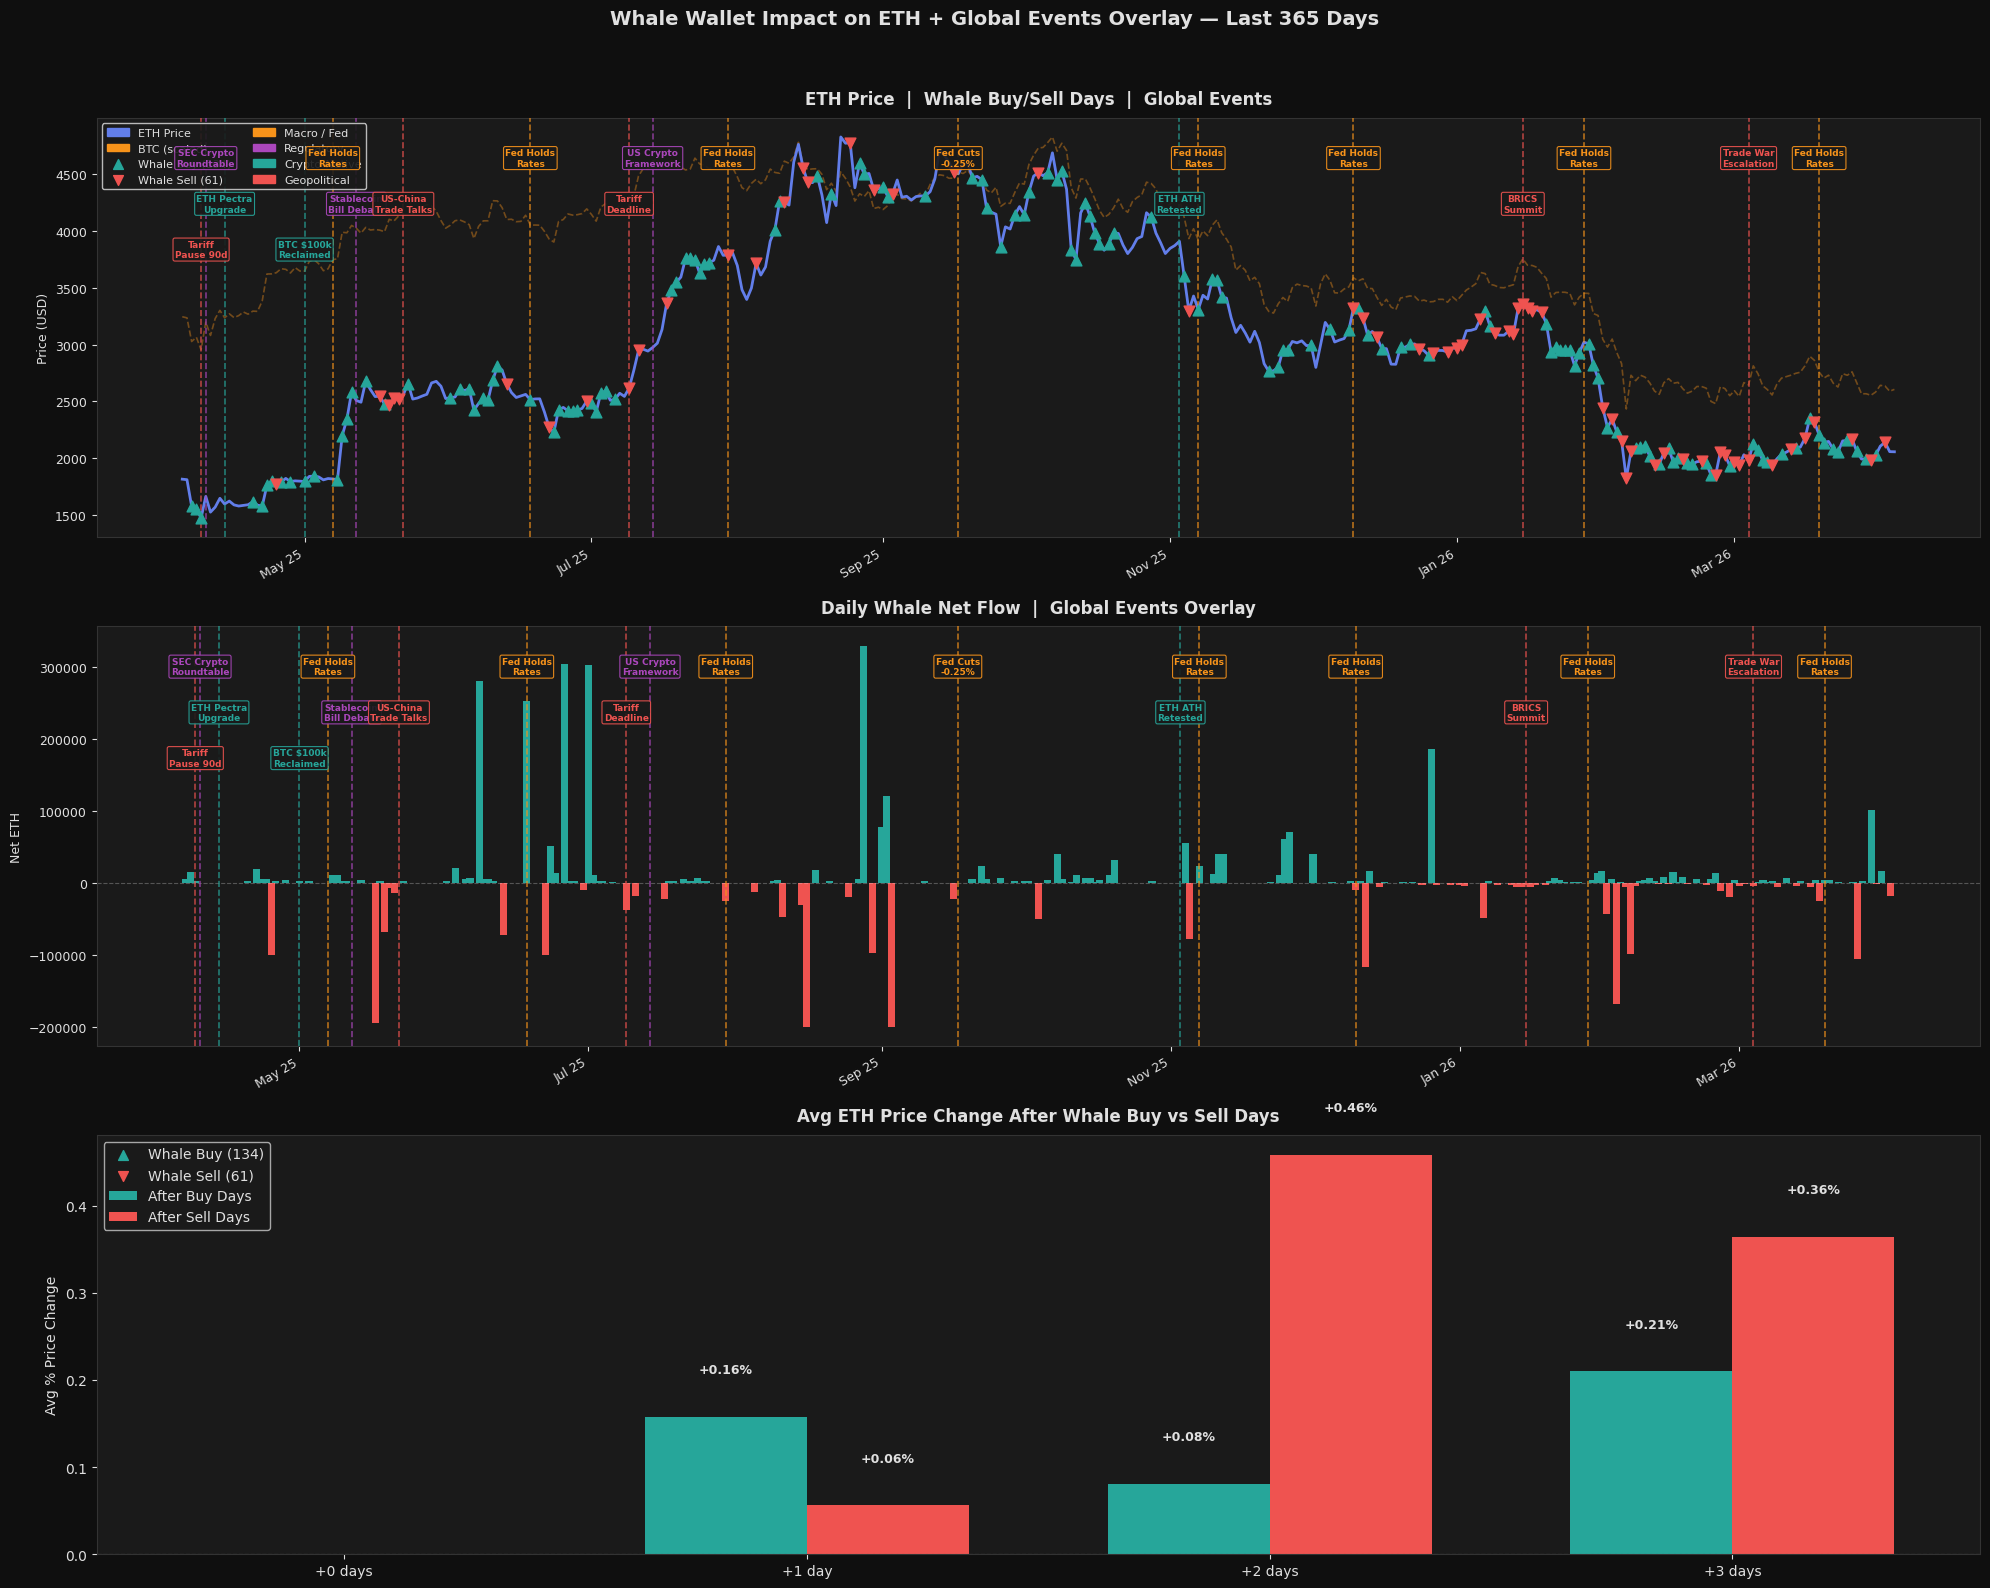

  Chart saved → whale_impact_report.png


In [7]:
import requests
import time
from decimal import Decimal
from datetime import datetime, timedelta
from collections import defaultdict
import statistics
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

# ── Config ────────────────────────────────────────────────────────────────────

ETHERSCAN_KEY   = "2M4Z6AH3QBFCIXPCJHCQ2F12S1CFWIEZKJ"
ETHERSCAN_URL   = "https://api.etherscan.io/v2/api"
COINGECKO_URL   = "https://api.coingecko.com/api/v3"
WEI_TO_ETH      = Decimal("1e18")

WHALE_THRESHOLD = Decimal("50")
DAYS_TO_ANALYZE = 365
LAG_DAYS        = [0, 1, 2, 3]

WHALE_WALLETS = {
    "0xbe0eb53f46cd790cd13851d5eff43d12404d33e8": "Binance 7",
    "0x40b38765696e3d5d8d9d834d8aad4bb6e418e489": "Robinhood",
    "0x0e58e8993100f1cbe45376c410f97f4893d9bfcd": "Upbit 41",
    "0xafcd96e580138cfa2332c632e66308eacd45c5da": "Gemini: Cold Wallet",
    "0xe92d1a43df510f82c66382592a047d288f85226f": "Bitfinex 19",
    "0x73af3bcf944a6559933396c1577b257e2054d935": "Robinhood 6",
    "0x9f1799fb47b1514f453bcebbc37ecfe883756e83": "Kraken: Cold Wallet 4",
    "0xf977814e90da44bfa03b6295a0616a897441acec": "Binance: Hot Wallet 20",
    "0x220866b1a2219f40e72f5c628b65d54268ca3a9d": "Vb 3",
    "0x8d05d9924fe935bd533a844271a1b2078eae6fcf": "Kraken: Cold Wallet 3",
}

# ── Global Events ─────────────────────────────────────────────────────────────
# Format: ("YYYY-MM-DD", "Label", "category")
# Categories: "macro", "regulatory", "crypto", "geopolitical"

GLOBAL_EVENTS = [
    # Macro / Fed
    ("2025-05-07", "Fed Holds\nRates",         "macro"),
    ("2025-06-18", "Fed Holds\nRates",         "macro"),
    ("2025-07-30", "Fed Holds\nRates",         "macro"),
    ("2025-09-17", "Fed Cuts\n-0.25%",         "macro"),
    ("2025-11-07", "Fed Holds\nRates",         "macro"),
    ("2025-12-10", "Fed Holds\nRates",         "macro"),
    ("2026-01-28", "Fed Holds\nRates",         "macro"),
    ("2026-03-19", "Fed Holds\nRates",         "macro"),

    # Regulatory
    ("2025-04-10", "SEC Crypto\nRoundtable",   "regulatory"),
    ("2025-05-12", "Stablecoin\nBill Debate",  "regulatory"),
    ("2025-07-14", "US Crypto\nFramework",     "regulatory"),

    # Crypto-native
    ("2025-04-14", "ETH Pectra\nUpgrade",      "crypto"),
    ("2025-05-01", "BTC $100k\nReclaimed",     "crypto"),
    ("2025-11-03", "ETH ATH\nRetested",        "crypto"),

    # Geopolitical
    ("2025-04-09", "Tariff\nPause 90d",        "geopolitical"),
    ("2025-05-22", "US-China\nTrade Talks",    "geopolitical"),
    ("2025-07-09", "Tariff\nDeadline",         "geopolitical"),
    ("2026-01-15", "BRICS\nSummit",            "geopolitical"),
    ("2026-03-04", "Trade War\nEscalation",    "geopolitical"),
]

EVENT_COLORS = {
    "macro":       "#f7931a",   # orange
    "regulatory":  "#ab47bc",   # purple
    "crypto":      "#26a69a",   # teal
    "geopolitical":"#ef5350",   # red
}

EVENT_LABELS = {
    "macro":       "Macro / Fed",
    "regulatory":  "Regulatory",
    "crypto":      "Crypto-Native",
    "geopolitical":"Geopolitical",
}


# ── Data Fetching ─────────────────────────────────────────────────────────────

def get_eth_market_history(days=DAYS_TO_ANALYZE):
    url    = f"{COINGECKO_URL}/coins/ethereum/market_chart"
    params = {"vs_currency": "usd", "days": days, "interval": "daily"}
    prices, volumes = {}, {}
    try:
        data = requests.get(url, params=params, timeout=10).json()
        for ts, p in data.get("prices", []):
            d = datetime.utcfromtimestamp(float(ts)/1000).strftime("%Y-%m-%d")
            prices[d] = float(p)
        for ts, v in data.get("total_volumes", []):
            d = datetime.utcfromtimestamp(float(ts)/1000).strftime("%Y-%m-%d")
            volumes[d] = float(v)
    except Exception as e:
        print(f"[!] CoinGecko ETH error: {e}")
    return prices, volumes


def get_btc_price_history(days=DAYS_TO_ANALYZE):
    url    = f"{COINGECKO_URL}/coins/bitcoin/market_chart"
    params = {"vs_currency": "usd", "days": days, "interval": "daily"}
    prices = {}
    try:
        data = requests.get(url, params=params, timeout=10).json()
        for ts, p in data.get("prices", []):
            d = datetime.utcfromtimestamp(float(ts)/1000).strftime("%Y-%m-%d")
            prices[d] = float(p)
    except Exception as e:
        print(f"[!] CoinGecko BTC error: {e}")
    return prices


def get_whale_transactions(address, days=DAYS_TO_ANALYZE):
    cutoff  = int((datetime.now() - timedelta(days=days)).timestamp())
    all_txs = []
    page    = 1
    while True:
        params = {
            "chainid": 1, "module": "account", "action": "txlist",
            "address": address, "startblock": 0, "endblock": 99999999,
            "page": page, "offset": 1000, "sort": "desc", "apikey": ETHERSCAN_KEY,
        }
        try:
            data = requests.get(ETHERSCAN_URL, params=params, timeout=10).json()
        except Exception as e:
            print(f"  [!] Request error: {e}"); break
        if data["status"] != "1":
            break
        txs = [t for t in data["result"] if int(t["timeStamp"]) >= cutoff]
        all_txs.extend(txs)
        if len(data["result"]) < 1000 or int(data["result"][-1]["timeStamp"]) < cutoff:
            break
        page += 1
        time.sleep(0.25)
    return all_txs


# ── Analysis ──────────────────────────────────────────────────────────────────

def classify_whale_days(all_whale_txs):
    daily = defaultdict(lambda: {"inflow": Decimal(0), "outflow": Decimal(0), "tx_count": 0})
    for address, txs in all_whale_txs.items():
        for tx in txs:
            val = Decimal(tx["value"]) / WEI_TO_ETH
            if val < WHALE_THRESHOLD or tx.get("isError") == "1":
                continue
            date = datetime.fromtimestamp(int(tx["timeStamp"])).strftime("%Y-%m-%d")
            if tx["to"].lower() == address.lower():
                daily[date]["inflow"]  += val
            elif tx["from"].lower() == address.lower():
                daily[date]["outflow"] += val
            daily[date]["tx_count"] += 1
    for d in daily:
        daily[d]["net_flow"] = daily[d]["inflow"] - daily[d]["outflow"]
    return dict(daily)


def price_change(prices, date, lag):
    dates = sorted(prices.keys())
    if date not in dates: return None
    idx = dates.index(date)
    if idx + lag >= len(dates): return None
    p0, p1 = prices[date], prices[dates[idx + lag]]
    return ((p1 - p0) / p0) * 100 if p0 else None


def build_results(whale_days, eth_prices, volumes, btc_prices):
    avg_vol = statistics.mean(volumes.values()) if volumes else 1
    results = []
    for date, wd in sorted(whale_days.items()):
        net    = float(wd["net_flow"])
        signal = "ACCUMULATE" if net > 0 else "DISTRIBUTE"
        chgs   = {f"eth_chg_d{l}": (lambda c: round(c,4) if c else None)(price_change(eth_prices, date, l)) for l in LAG_DAYS}
        results.append({
            "date":      date,
            "signal":    signal,
            "net_flow":  round(net, 2),
            "inflow":    round(float(wd["inflow"]),  2),
            "outflow":   round(float(wd["outflow"]), 2),
            "whale_txs": wd["tx_count"],
            "eth_price": round(eth_prices.get(date, 0), 2),
            "btc_price": round(btc_prices.get(date, 0), 2),
            "vol_ratio": round(volumes.get(date, 0) / avg_vol, 3),
            "btc_chg_d1": (lambda c: round(c,4) if c else None)(price_change(btc_prices, date, 1)),
            **chgs,
        })
    return results


# ── Plotting ──────────────────────────────────────────────────────────────────

DARK  = "#0f0f0f"
PANEL = "#1a1a1a"
GREEN = "#26a69a"
RED   = "#ef5350"
BLUE  = "#627eea"
WHITE = "#e0e0e0"
GREY  = "#555555"

def style(ax, title, ylabel=""):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=WHITE, fontsize=12, fontweight="bold", pad=10)
    ax.tick_params(colors=WHITE, labelsize=9)
    ax.set_ylabel(ylabel, color=WHITE, fontsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#333")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha="right", color=WHITE)


def filter_events(eth_prices):
    dates = sorted(eth_prices.keys())
    min_date = (datetime.strptime(dates[0],  "%Y-%m-%d") - timedelta(days=2)).strftime("%Y-%m-%d")
    max_date = (datetime.strptime(dates[-1], "%Y-%m-%d") + timedelta(days=2)).strftime("%Y-%m-%d")
    return [(d, lbl, cat) for d, lbl, cat in GLOBAL_EVENTS if min_date <= d <= max_date]


def add_event_lines(ax, events, y_max, y_min):
    """Draw vertical lines + labels for each global event."""
    span       = y_max - y_min
    used_dates = {}

    for date_str, label, cat in events:
        dt    = datetime.strptime(date_str, "%Y-%m-%d")
        color = EVENT_COLORS[cat]

        ax.axvline(dt, color=color, lw=1.2, alpha=0.7, linestyle="--", zorder=3)

        # Stagger label heights for nearby events
        offset_count = sum(
            1 for d in used_dates
            if abs((datetime.strptime(d, "%Y-%m-%d") - dt).days) < 14
        )
        y_pos = y_max - span * (0.03 + offset_count * 0.12)
        used_dates[date_str] = y_pos

        ax.text(
            dt, y_pos, label,
            color=color, fontsize=6.5, fontweight="bold",
            ha="center", va="top",
            bbox=dict(boxstyle="round,pad=0.2", facecolor=PANEL,
                      edgecolor=color, alpha=0.9, lw=0.8),
            zorder=6,
        )


def debug_events(eth_prices):
    all_dates = sorted(eth_prices.keys())
    print(f"\n[DEBUG] Price data range: {all_dates[0]} → {all_dates[-1]}")
    print(f"[DEBUG] Events in window:")
    for date_str, label, cat in GLOBAL_EVENTS:
        in_range = all_dates[0] <= date_str <= all_dates[-1]
        print(f"  {'✓' if in_range else '✗'} {date_str}  {label.replace(chr(10),' ')}  ({cat})")

def plot_all(results, eth_prices, btc_prices, volumes):
    all_dates = sorted(set(eth_prices) & set(btc_prices))
    all_dt    = [datetime.strptime(d, "%Y-%m-%d") for d in all_dates]
    eth_vals  = [eth_prices[d] for d in all_dates]
    btc_norm  = [btc_prices[d] / max(btc_prices.values()) * max(eth_prices.values()) for d in all_dates]

    acc_rows  = [r for r in results if r["signal"] == "ACCUMULATE"]
    dist_rows = [r for r in results if r["signal"] == "DISTRIBUTE"]
    acc_dt    = [datetime.strptime(r["date"], "%Y-%m-%d") for r in acc_rows]
    dist_dt   = [datetime.strptime(r["date"], "%Y-%m-%d") for r in dist_rows]
    acc_px    = [r["eth_price"] for r in acc_rows]
    dist_px   = [r["eth_price"] for r in dist_rows]

    dates_dt  = [datetime.strptime(r["date"], "%Y-%m-%d") for r in results]
    net_flows = [r["net_flow"] for r in results]
    f_colors  = [GREEN if n > 0 else RED for n in net_flows]

    def avg_lag(rows, lag):
        vals = [r[f"eth_chg_d{lag}"] for r in rows if r.get(f"eth_chg_d{lag}") is not None]
        return round(statistics.mean(vals), 3) if vals else 0

    events = filter_events(eth_prices)
    debug_events(eth_prices)
    print(f"[DEBUG] Events passing filter: {len(events)}")
    print(f"[DEBUG] ETH y range: {min(eth_vals):.2f} → {max(eth_vals):.2f}")

    fig, axes = plt.subplots(3, 1, figsize=(20, 16), facecolor=DARK)
    fig.suptitle(
        f"Whale Wallet Impact on ETH + Global Events Overlay — Last {DAYS_TO_ANALYZE} Days",
        color=WHITE, fontsize=14, fontweight="bold", y=0.99
    )

    # ── Chart 1: ETH price + BTC + whale signals + global events ──
    ax1 = axes[0]
    style(ax1, "ETH Price  |  Whale Buy/Sell Days  |  Global Events", ylabel="Price (USD)")
    ax1.plot(all_dt, eth_vals, color=BLUE,   lw=2,   label="ETH Price", zorder=2)
    ax1.plot(all_dt, btc_norm, color="#f7931a", lw=1.2, linestyle="--", alpha=0.4, label="BTC (scaled)", zorder=1)
    ax1.scatter(acc_dt,  acc_px,  color=GREEN, s=60, zorder=5, marker="^", label=f"Whale Buy  ({len(acc_rows)} days)")
    ax1.scatter(dist_dt, dist_px, color=RED,   s=60, zorder=5, marker="v", label=f"Whale Sell ({len(dist_rows)} days)")

    y_min, y_max = min(eth_vals), max(eth_vals)
    add_event_lines(ax1, events, y_max, y_min)

    # Legend: whale signals + event categories
    whale_handles = [
        mpatches.Patch(color=BLUE,  label="ETH Price"),
        mpatches.Patch(color="#f7931a", label="BTC (scaled)"),
        plt.scatter([], [], color=GREEN, marker="^", s=50, label=f"Whale Buy ({len(acc_rows)})"),
        plt.scatter([], [], color=RED,   marker="v", s=50, label=f"Whale Sell ({len(dist_rows)})"),
    ]
    event_handles = [mpatches.Patch(color=c, label=EVENT_LABELS[k]) for k, c in EVENT_COLORS.items()]
    ax1.legend(handles=whale_handles + event_handles,
               facecolor=PANEL, labelcolor=WHITE, fontsize=8,
               loc="upper left", ncol=2, framealpha=0.9)

    # ── Chart 2: Whale net flow + event lines ──
    ax2 = axes[1]
    style(ax2, "Daily Whale Net Flow  |  Global Events Overlay", ylabel="Net ETH")
    ax2.bar(dates_dt, net_flows, color=f_colors, width=1.5, zorder=2)
    ax2.axhline(0, color=WHITE, lw=0.8, alpha=0.3, linestyle="--")

    flow_min, flow_max = min(net_flows), max(net_flows)
    add_event_lines(ax2, events, flow_max, flow_min)

    # ── Chart 3: Avg price change by lag ──
    ax3 = axes[2]
    ax3.set_facecolor(PANEL)
    ax3.set_title("Avg ETH Price Change After Whale Buy vs Sell Days", color=WHITE, fontsize=12, fontweight="bold", pad=10)
    ax3.tick_params(colors=WHITE, labelsize=10)
    for spine in ax3.spines.values(): spine.set_edgecolor("#333")

    lag_labels = [f"+{l} day{'s' if l != 1 else ''}" for l in LAG_DAYS]
    x = range(len(LAG_DAYS))
    w = 0.35
    acc_vals  = [avg_lag(acc_rows,  l) for l in LAG_DAYS]
    dist_vals = [avg_lag(dist_rows, l) for l in LAG_DAYS]

    b_acc  = ax3.bar([p - w/2 for p in x], acc_vals,  width=w, color=GREEN, label="After Buy Days",  zorder=2)
    b_dist = ax3.bar([p + w/2 for p in x], dist_vals, width=w, color=RED,   label="After Sell Days", zorder=2)
    ax3.axhline(0, color=WHITE, lw=0.8, alpha=0.4, linestyle="--")
    ax3.set_xticks(list(x))
    ax3.set_xticklabels(lag_labels, color=WHITE, fontsize=10)
    ax3.set_ylabel("Avg % Price Change", color=WHITE, fontsize=10)
    ax3.legend(facecolor=PANEL, labelcolor=WHITE, fontsize=10)

    for bar in list(b_acc) + list(b_dist):
        h = bar.get_height()
        if h != 0:
            ax3.text(
                bar.get_x() + bar.get_width() / 2,
                h + (0.05 if h >= 0 else -0.15),
                f"{h:+.2f}%", ha="center", color=WHITE, fontsize=9, fontweight="bold"
            )

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig("whale_impact_report.png", dpi=150, bbox_inches="tight", facecolor=DARK)
    plt.show()
    print("  Chart saved → whale_impact_report.png")


# ── Summary Print ─────────────────────────────────────────────────────────────

def summarize(results, eth_prices, btc_prices):
    acc  = [r for r in results if r["signal"] == "ACCUMULATE"]
    dist = [r for r in results if r["signal"] == "DISTRIBUTE"]

    def avg(rows, key):
        vals = [r[key] for r in rows if r.get(key) is not None]
        return round(statistics.mean(vals), 4) if vals else None

    print("\n" + "="*65)
    print("  WHALE WALLET IMPACT MODEL — SUMMARY")
    print("="*65)
    print(f"  Period          : Last {DAYS_TO_ANALYZE} days")
    print(f"  Whale wallets   : {len(WHALE_WALLETS)}")
    print(f"  Whale threshold : > {WHALE_THRESHOLD} ETH per tx")
    print(f"  Whale buy days  : {len(acc)}")
    print(f"  Whale sell days : {len(dist)}")
    print(f"  Global events   : {len([e for e in GLOBAL_EVENTS if min(eth_prices) <= e[0] <= max(eth_prices)])} in window")

    for label, rows in [("BUY DAYS", acc), ("SELL DAYS", dist)]:
        print(f"\n  ETH price change after whale {label}:")
        for lag in LAG_DAYS:
            c = avg(rows, f"eth_chg_d{lag}")
            print(f"    +{lag}d : {'▲' if c and c > 0 else '▼'} {c:>+.4f}%" if c else f"    +{lag}d : N/A")

    print(f"\n  Top 5 biggest whale moves:")
    for r in sorted(results, key=lambda x: abs(x["net_flow"]), reverse=True)[:5]:
        e      = r.get("eth_chg_d1")
        nearby = [lbl for d, lbl, _ in GLOBAL_EVENTS if abs((datetime.strptime(d, "%Y-%m-%d") - datetime.strptime(r["date"], "%Y-%m-%d")).days) <= 3]
        note   = f"  ← near: {', '.join(nearby)}" if nearby else ""
        sig    = "BUY " if r["signal"] == "ACCUMULATE" else "SELL"
        print(f"  {r['date']}  [{sig}]  {r['net_flow']:>12.0f} ETH  ETH+1d: {f'{e:+.2f}%' if e else 'N/A'}{note}")

    print(f"\n  Interpretation:")
    a1 = avg(acc,  "eth_chg_d1")
    d1 = avg(dist, "eth_chg_d1")
    if a1: print(f"  {'✓' if a1 > 0 else '✗'} Whale buying  → ETH {'rises' if a1 > 0 else 'falls'} next day on avg ({a1:+.2f}%)")
    if d1: print(f"  {'✓' if d1 < 0 else '✗'} Whale selling → ETH {'drops' if d1 < 0 else 'rises'} next day on avg ({d1:+.2f}%)")
    print()


# ── Main ──────────────────────────────────────────────────────────────────────

print("Fetching market data...")
eth_prices, volumes = get_eth_market_history(DAYS_TO_ANALYZE)
btc_prices          = get_btc_price_history(DAYS_TO_ANALYZE)
print(f"  ETH: {len(eth_prices)} days  |  BTC: {len(btc_prices)} days  |  Volume: {len(volumes)} days")

print("\nFetching whale transactions (365 days — takes a few minutes)...")
all_whale_txs = {}
for address, name in WHALE_WALLETS.items():
    print(f"  Scanning {name}...")
    txs = get_whale_transactions(address, DAYS_TO_ANALYZE)
    all_whale_txs[address] = txs
    print(f"    → {len(txs)} txs")
    time.sleep(0.3)

print("\nAnalyzing...")
whale_days = classify_whale_days(all_whale_txs)
results    = build_results(whale_days, eth_prices, volumes, btc_prices)
summarize(results, eth_prices, btc_prices)
plot_all(results, eth_prices, btc_prices, volumes)